<a href="https://colab.research.google.com/github/nawaltahir/codealpha_tasks/blob/main/Access_Control_System_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import os
import zipfile

files.upload()  # Upload kaggle.json here
# Create the Kaggle directory and move the token there
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/kaggle.json

# Set permissions
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!pip install -q kaggle

# Download the dataset
!kaggle datasets download -d hearfool/vggface2


Dataset URL: https://www.kaggle.com/datasets/hearfool/vggface2
License(s): unknown


In [ ]:
# unzip the file
!unzip -q vggface2.zip

In [ ]:
!pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 72.6 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=20054a12afd0f27d9650897c43e4eafe039ef44425e3485df3ff899350ef7d45
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
import os

train_path = 'train'

train_identities = os.listdir(train_path)
print("Available training identities:", train_identities)

test_path = 'val'

test_identities = os.listdir(test_path)
print("Available testing identities:", test_identities)

Available training identities: ['n000369', 'n000109', 'n000272', 'n000217', 'n000265', 'n000442', 'n000074', 'n000237', 'n000385', 'n000483', 'n000381', 'n000466', 'n000315', 'n000411', 'n000295', 'n000195', 'n000412', 'n000498', 'n000043', 'n000377', 'n000432', 'n000416', 'n000477', 'n000280', 'n000021', 'n000290', 'n000102', 'n000220', 'n000264', 'n000063', 'n000397', 'n000318', 'n000042', 'n000173', 'n000297', 'n000097', 'n000345', 'n000069', 'n000206', 'n000362', 'n000476', 'n000435', 'n000142', 'n000288', 'n000135', 'n000451', 'n000353', 'n000224', 'n000338', 'n000405', 'n000174', 'n000240', 'n000251', 'n000324', 'n000393', 'n000015', 'n000310', 'n000281', 'n000445', 'n000003', 'n000266', 'n000087', 'n000374', 'n000071', 'n000081', 'n000022', 'n000303', 'n000268', 'n000115', 'n000337', 'n000250', 'n000379', 'n000494', 'n000156', 'n000463', 'n000257', 'n000096', 'n000332', 'n000361', 'n000441', 'n000356', 'n000049', 'n000386', 'n000059', 'n000221', 'n000307', 'n000141', 'n000339', 

In [ ]:
# Example: pick two images manually
authorized_image_path = os.path.join(train_path, train_identities[0], os.listdir(os.path.join(train_path, train_identities[0]))[0])
test_image_path = os.path.join(test_path, test_identities[1], os.listdir(os.path.join(test_path, test_identities[1]))[0])

print("Authorized:", authorized_image_path)
print("Test:", test_image_path)


Authorized: train/n000369/0215_02.jpg
Test: val/n000836/0103_01.jpg


In [ ]:
from deepface import DeepFace

# Verify
result = DeepFace.verify(img1_path=authorized_image_path, img2_path=test_image_path, model_name="ArcFace")

# Result
if result['verified']:
    print("Access Granted! Same person.")
else:
    print("Access Denied! Different person.")


Access Denied! Different person.


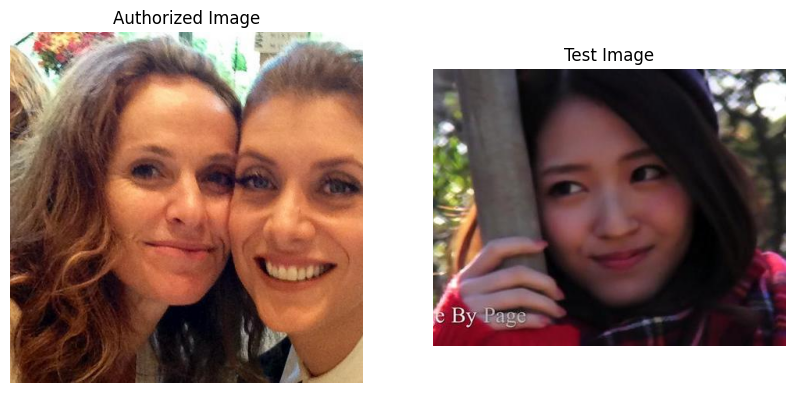

In [ ]:
import cv2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10,5))
ax[0].imshow(cv2.cvtColor(cv2.imread(authorized_image_path), cv2.COLOR_BGR2RGB))
ax[0].set_title('Authorized Image')
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(cv2.imread(test_image_path), cv2.COLOR_BGR2RGB))
ax[1].set_title('Test Image')
ax[1].axis('off')
plt.show()


In [ ]:
import os
import random
from deepface import DeepFace
from tqdm import tqdm

# List of available people
train_people = os.listdir(train_path)
test_people = os.listdir(test_path)

print("Train identities", (train_identities))
print("Test identities", (test_identities))

# Function to pick a random image from a person's folder
def pick_random_image(base_path, person_id):
    person_folder = os.path.join(base_path, person_id)
    images = os.listdir(person_folder)
    img_path = os.path.join(person_folder, random.choice(images))
    return img_path

# Batch testing
num_tests = 50
correct = 0

for _ in tqdm(range(num_tests)):

    same_person = random.choice([True, False])

    if same_person:
        # Get the common identities between train and test sets
        common_identities = list(set(train_identities) & set(test_identities))

        # Check if there are any common identities
        if not common_identities:
            # If no common identities, skip this iteration and continue
            continue

        person = random.choice(common_identities)  # Now pick from common_identities
        img1 = pick_random_image(train_path, person)
        img2 = pick_random_image(test_path, person)
    else:
        person1 = random.choice(train_people)
        person2 = random.choice(test_people)
        while person1 == person2:
            person2 = random.choice(test_people)
        img1 = pick_random_image(train_path, person1)
        img2 = pick_random_image(test_path, person2)

    # DeepFace Verification
    try:
        result = DeepFace.verify(img1_path=img1, img2_path=img2, model_name="VGG-Face", enforce_detection=False)

        if result['verified'] == same_person:
            correct += 1
    except Exception as e:
        print(f"Error comparing images: {e}")

# Final Accuracy
accuracy = (correct / num_tests) * 100
print(f"\n Batch Test Completed! Accuracy: {accuracy:.2f}% over {num_tests} tests.")


25-04-21 14:37:35 - Directory /root/.deepface has been created
25-04-21 14:37:35 - Directory /root/.deepface/weights has been created
Train identities ['n000369', 'n000109', 'n000272', 'n000217', 'n000265', 'n000442', 'n000074', 'n000237', 'n000385', 'n000483', 'n000381', 'n000466', 'n000315', 'n000411', 'n000295', 'n000195', 'n000412', 'n000498', 'n000043', 'n000377', 'n000432', 'n000416', 'n000477', 'n000280', 'n000021', 'n000290', 'n000102', 'n000220', 'n000264', 'n000063', 'n000397', 'n000318', 'n000042', 'n000173', 'n000297', 'n000097', 'n000345', 'n000069', 'n000206', 'n000362', 'n000476', 'n000435', 'n000142', 'n000288', 'n000135', 'n000451', 'n000353', 'n000224', 'n000338', 'n000405', 'n000174', 'n000240', 'n000251', 'n000324', 'n000393', 'n000015', 'n000310', 'n000281', 'n000445', 'n000003', 'n000266', 'n000087', 'n000374', 'n000071', 'n000081', 'n000022', 'n000303', 'n000268', 'n000115', 'n000337', 'n000250', 'n000379', 'n000494', 'n000156', 'n000463', 'n000257', 'n000096', '

  0%|          | 0/50 [00:00<?, ?it/s]

25-04-21 14:37:36 - vgg_face_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5

  0%|          | 0.00/580M [00:00<?, ?B/s]
  4%|▍         | 23.6M/580M [00:00<00:02, 235MB/s]
 11%|█         | 64.5M/580M [00:00<00:01, 337MB/s]
 17%|█▋        | 98.6M/580M [00:01<00:10, 46.1MB/s]
 22%|██▏       | 130M/580M [00:01<00:06, 67.9MB/s] 
 28%|██▊       | 163M/580M [00:01<00:04, 94.7MB/s]
 34%|███▍      | 197M/580M [00:01<00:03, 127MB/s] 
 39%|███▉      | 227M/580M [00:02<00:02, 145MB/s]
 45%|████▌     | 263M/580M [00:02<00:01, 181MB/s]
 50%|█████     | 293M/580M [00:02<00:01, 194MB/s]
 57%|█████▋    | 331M/580M [00:02<00:01, 233MB/s]
 63%|██████▎   | 366M/580M [00:02<00:00, 262MB/s]
 70%|███████   | 409M/580M [00:02<00:00, 302MB/s]
 77%|███████▋  | 447M/580M [00:02<00:00, 321MB/s]
 83%|████████▎ | 483M/580M [00:02<00:00, 333MB/s]
 90%|████████▉ | 520M/580M [00:02<00:00, 335MB/s]
100%|██████████| 580M/580M [00:03<00:00, 1


 Batch Test Completed! Accuracy: 48.00% over 50 tests.


In [ ]:
import numpy as np
from deepface import DeepFace
import os
import random
from tqdm import tqdm

def get_embeddings(base_path, people):
    embeddings = []
    labels = []

    for person in tqdm(people, desc="Extracting embeddings"):
        person_folder = os.path.join(base_path, person)
        images = os.listdir(person_folder)

        for img_name in images:
            img_path = os.path.join(person_folder, img_name)
            try:
                embedding = DeepFace.represent(img_path=img_path, model_name="Facenet512", enforce_detection=False, detector_backend='skip')
                embeddings.append(embedding[0]['embedding'])
                labels.append(person)
            except Exception as e:
                print(f"Error processing {img_path}: {e}")

    return np.array(embeddings), np.array(labels)

train_embeddings, train_labels = get_embeddings(train_path, train_identities)
test_embeddings, test_labels = get_embeddings(test_path, test_identities)


25-04-22 13:26:08 - Directory /root/.deepface has been created
25-04-22 13:26:08 - Directory /root/.deepface/weights has been created


Extracting embeddings:   0%|          | 0/480 [00:00<?, ?it/s]

25-04-22 13:26:12 - facenet512_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /root/.deepface/weights/facenet512_weights.h5

  0%|          | 0.00/95.0M [00:00<?, ?B/s]
 12%|█▏        | 11.0M/95.0M [00:00<00:02, 41.1MB/s]
 23%|██▎       | 21.5M/95.0M [00:00<00:01, 40.3MB/s]
 34%|███▎      | 32.0M/95.0M [00:00<00:01, 37.6MB/s]
 45%|████▍     | 42.5M/95.0M [00:01<00:01, 38.8MB/s]
 56%|█████▌    | 53.0M/95.0M [00:01<00:01, 38.9MB/s]
 67%|██████▋   | 63.4M/95.0M [00:01<00:00, 38.6MB/s]
 78%|███████▊  | 73.9M/95.0M [00:01<00:00, 38.7MB/s]
 89%|████████▉ | 84.4M/95.0M [00:02<00:00, 38.3MB/s]
100%|██████████| 95.0M/95.0M [00:02<00:00, 38.6MB/s]
Extracting embeddings:  40%|████      | 193/480 [4:05:31<6:01:28, 75.57s/it]